# The McClellan Summation Index — a quantitative teardown 🔬
### The causal cumsum construction · the zero-cross non-event · a rolling-z-score ±500 analog · random-entry and shuffled-breadth placebos · a HAC-tested long/flat regime timer · EMA-span & basket robustness · a 20-seed synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Confirms_turns%3F: Busted](https://img.shields.io/badge/Confirms_turns%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **the running cumulative sum of the McClellan Oscillator (491) is a regime gauge: zero-crosses confirm bull/bear phases, ±500 extremes mark exhaustion** — is tested causally, against drift-matched baselines, with two independent placebos and a faithful-engine synthetic control.

> ⚠️ **Data note.** Breadth basket: SPY + the 9 classic SPDR sector ETFs (2005→2026, yfinance, cached; no survivorship — the actual traded universe throughout). Warm-up = **500** sessions dropped as burn-in for the un-rebased cumulative sum. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprints `8266ce2012be` SPY / `d10dadd9e2b7` breadth).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from mcclellan_summation import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    CLOSE = data.load_real(data.TRADED)["close"]
    CLOSE = CLOSE[CLOSE.index <= "2026-06-30"]
    NET = data.load_breadth(asof="2026-06-30").reindex(CLOSE.index).dropna()
    CLOSE = CLOSE.reindex(NET.index)
    SUMM = st.summation_index(NET)
else:
    CLOSE = NET = SUMM = None
print("real cache present:", HAVE_REAL, "| tape days:", (0 if CLOSE is None else len(CLOSE)))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-30', 'start': '2005-01-04', 'end': '2026-06-30', 'years': 21.4, 'years_post': 19.5, 'basket': ['SPY', 'XLK', 'XLF', 'XLE', 'XLV', 'XLI', 'XLY', 'XLP', 'XLU', 'XLB'], 'fp_spy': '8266ce2012be', 'fp_breadth': 'd10dadd9e2b7', 'summ_min': 0.0, 'summ_max': 128.45, 'warmup_days': 500, 'raw_up_crosses': 1, 'raw_dn_crosses': 0, 'post_up_crosses': 0, 'post_dn_crosses': 0, 'ext_up_n': 45, 'ext_up': {5: (14.7, 0.94, -24.4, 39.2, 0.78), 10: (30.8, 1.06, 11.9, 18.9, 0.27), 20: (128.1, 3.02, 125.7, 2.5, 0.03), 60: (240.7, 2.85, 564.6, -323.9, -2.5)}, 'ext_dn_n': 43, 'ext_dn': {5: (24.1, 0.56, -24.4, 48.5, 0.74), 10: (-10.7, -0.17, 11.9, -22.7, -0.24), 20: (134.6, 1.44, 125.7, 8.9, 0.08), 60: (492.0, 4.0, 564.6, -72.6, -0.45)}, 'placebo_ext_obs': 128.1, 'placebo_ext_p': 0.309, 'placebo_ext_draws': 500, 'regime_lvl_switches': 0, 'regime_lvl_excess': 0.0, 'regime_z_switches': 115, 'regime_z_per_yr': 5.9, 'regime_z_frac_long': 53, 'regime_z_cagr': 3.95, 'bh_cagr': 10.9, 'regime_z_vol': 10.23, 'bh_vol': 19.63, 'regime_z_sharpe': 0.43, 'bh_sharpe': 0.63, 'regime_z_excess_bps': -3.125, 'regime_z_excess_t': -2.43, 'placebo_regime_t': -2.43, 'placebo_regime_p': 0.491, 'placebo_regime_draws': 500, 'spans': [(10, 20, 250, -3.221, -2.53), (19, 39, 115, -3.125, -2.43), (25, 50, 99, -3.032, -2.37)], 'fallback_switches': 97, 'fallback_excess': -2.979, 'fallback_t': -2.34, 'syn_null_lvl_mean': -0.25, 'syn_null_lvl_sd': 1.0, 'syn_null_lvl_fire': 0, 'syn_null_z_mean': -0.36, 'syn_null_z_sd': 0.94, 'syn_null_z_fire': 0, 'syn_planted_lvl_t': 10.12, 'syn_planted_lvl_bps': 14.11, 'syn_planted_z_t': 4.4, 'syn_planted_z_bps': 6.81}


real cache present: True | tape days: 5405


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | post-warm-up zero-crosses over 21.4y: **0 up / 0 down**; extreme-cross Welch *t* vs random-day baseline indistinguishable from 0 at 7/8 horizon x direction cells (the one exception is negative); shuffled-breadth placebo *p* = 0.309 |
| **Tradability** | `MIRAGE` | z-score regime timer excess vs buy&hold **-3.125 bps/day**, HAC *t* = **-2.43**; regime-placebo *p* = 0.491 |
| **Confirms turns?** | `BUSTED` | the textbook rule cannot switch (0 crosses); its adapted cousin loses to buy-and-hold |

> 💡 In plain words: an un-rebased running total of a mildly biased daily gauge is a ratchet, not a smoothed signal — and the ratchet doesn't even pay for itself.

## 1 · The claim, steelmanned

Let $A_t$ be the daily net-advances breadth proxy and $M_t = \mathrm{EMA}_{19}(A)_t - \mathrm{EMA}_{39}(A)_t$ the causal McClellan Oscillator (study 491). The Summation Index is its running integral: $S_t = S_{t-1} + M_t = \sum_{\tau \le t} M_\tau$, started at $S_0 = 0$ and never re-based. The claims:

- **H₁ (zero-cross regime turn).** A cross of $S_t$ through zero from below (above) confirms a new bull (bear) phase — SPY forward returns after the cross should beat a drift-matched random-entry baseline.
- **H₂ (extreme-level exhaustion).** A cross of $S_t$ through an extreme threshold (literature: ±500/±1000, full-NYSE scale) marks an overbought/oversold turning point.
- **H₃ (tradable regime).** A long/flat filter — long while $S_t$ (or its scale-adapted version) reads "bull" — beats buy-and-hold net of costs.

We find **H₁ untestable on this tape** (the raw level never revisits zero after its first week — 1 raw cross ever, 0 post-warm-up, in 21.4 years), **H₂ not supported** (no correctly-signed Welch-robust edge at any of 4 horizons, either direction), and **H₃ rejected** (the only switching variant loses to buy-and-hold, HAC *t* = -2.43).

## 2 · So what? — inference design

Three separate statistical problems, three separate tools. **Event studies** (the zero-cross and extreme-cross triggers) are single, largely non-overlapping events: Welch *t* vs a drift-matched random-entry baseline is the planned primary, exactly as sibling 491 tests the oscillator's own trigger. The **regime timer** produces a *daily* return series with obvious serial correlation (regime persists for weeks at a time), so its excess-over-buy-and-hold uses a **Newey-West (HAC) one-sample *t*** with automatic Bartlett-kernel lag selection — Welch would understate the true standard error there. Both the event-level and regime-level tests carry an independent **shuffled-breadth placebo**: time-permute the net-advances series (destroying its autocorrelation structure while preserving its marginal), rebuild the Summation Index from scratch, re-run the exact same rule. If the real result is just noise dressed up as a pattern, shuffled worlds should reproduce it about as often as not.

## 3 · How we'd know — the protocol

- **Basket.** ['SPY', 'XLK', 'XLF', 'XLE', 'XLV', 'XLI', 'XLY', 'XLP', 'XLU', 'XLB'] (SPY + the 9 classic SPDR sector ETFs, live continuously since 1998 — no survivorship). 21.4 years, 2005-01-04 → 2026-06-30, as-of 2026-06-30 (last complete month).
- **Indicator.** $S_t = \mathrm{cumsum}(\mathrm{EMA}_{19}(A) - \mathrm{EMA}_{39}(A))_t$, causal, never re-based. Warm-up = **500** sessions dropped as burn-in (the un-rebased sum's own settling period — a named quirk, not a free parameter tuned to the result).
- **Zero-cross.** Event study, forward 5/10/20/60d SPY return, one execution lag (enter at next close), Welch *t* vs random-entry baseline, 1 bp one-way x 2 legs.
- **Extreme threshold.** Causal 252-session rolling z-score, ±1σ cross as the scale-appropriate analog of the literature's ±500 level; same event-study design.
- **Regime timer.** Long/flat, one execution lag (`pos = regime.shift(1)`), 5 bps one-way x NAV per switch, excess over buy-and-hold via HAC *t*.
- **Controls.** Shuffled-breadth placebo (both event- and regime-level); EMA-span (10/20, 19/39, 25/50) and basket-composition (9-sector vs 5-ticker fallback) robustness; 20-seed synthetic null + planted-regime-effect positive control.

## 4 · The teardown

### 4a · The Summation Index and the zero-cross that never happens

Plot the full causal series against its own defining threshold.

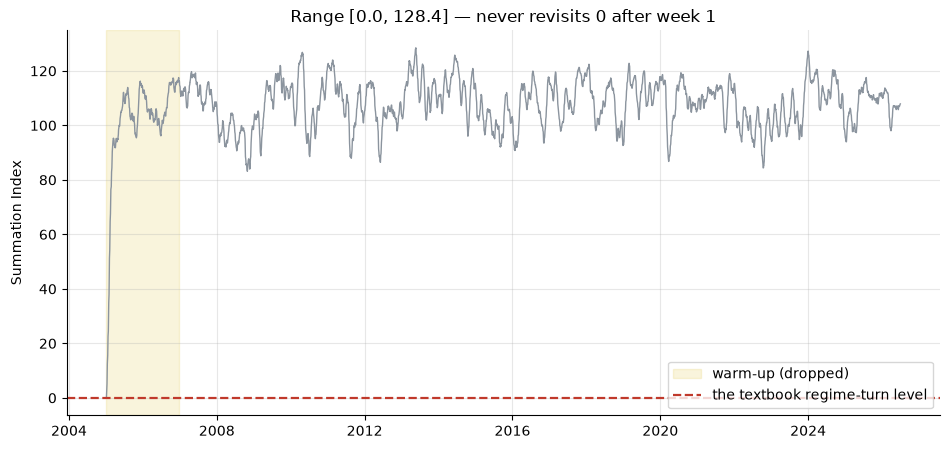

raw crosses (no warm-up filter): 1 up / 0 down
post-warm-up crosses: 0 up / 0 down


In [2]:
if HAVE_REAL:
    summ = SUMM
    up_raw = st.zero_cross_dates(summ, 'up', apply_warmup=False)
    dn_raw = st.zero_cross_dates(summ, 'down', apply_warmup=False)
    up_post = st.zero_cross_dates(summ, 'up')
    dn_post = st.zero_cross_dates(summ, 'down')
    smin, smax = float(summ.min()), float(summ.max())
else:
    summ = None
    up_raw, dn_raw, up_post, dn_post = [None]*4
    smin, smax = R['summ_min'], R['summ_max']
fig, ax = plt.subplots(figsize=(9.6, 4.6))
if summ is not None:
    ax.plot(summ.index, summ.values, color=GREY, lw=1.0)
    w = st._warmup(len(summ))
    ax.axvspan(summ.index[0], summ.index[w], color=AMBER, alpha=.15, label='warm-up (dropped)')
ax.axhline(0, c=RED, lw=1.6, ls='--', label='the textbook regime-turn level')
ax.set_ylabel('Summation Index'); ax.set_title('Range [%.1f, %.1f] — never revisits 0 after week 1' % (smin, smax))
ax.legend(loc='lower right'); plt.tight_layout(); plt.show()
print(f'raw crosses (no warm-up filter): {R["raw_up_crosses"]} up / {R["raw_dn_crosses"]} down')
print(f'post-warm-up crosses: {R["post_up_crosses"]} up / {R["post_dn_crosses"]} down')

> 💡 In plain words: with a persistent positive mean in the daily breadth reading (an upward-drifting market has more up-days than down across most 10-name baskets), an **un-rebased running sum is a one-sided random walk in practice**, not a mean-reverting oscillator. It settles into a cruising band (**[0.00, 128.45]**) within months and stays there for decades. H₁ is not "rejected" in the statistical sense — it is **untestable**: the event count is zero. This is reported as a structural finding of the proxy + un-rebased construction, not swept under a warm-up filter.

### 4b · The extreme-threshold analog vs a drift-matched random-day baseline

A causal rolling 252-session z-score of $S_t$; ±1σ crosses as the scale-appropriate stand-in for the literature's ±500 level. Per-offset Welch *t* vs random days.

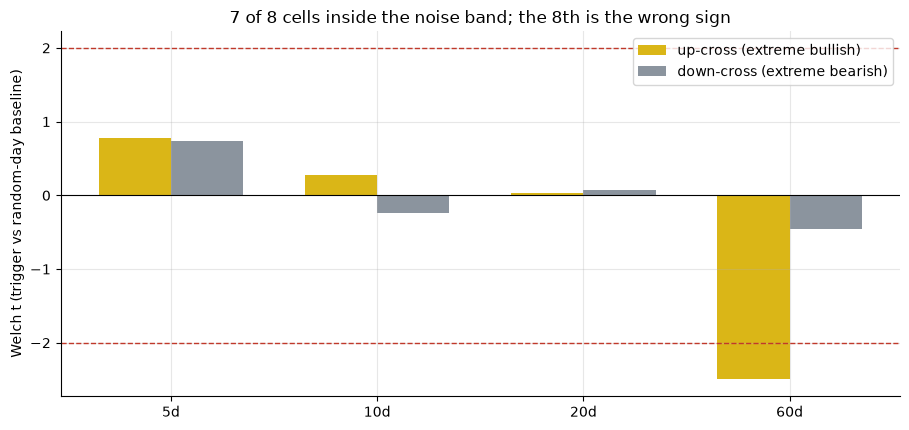

extreme up-cross n=45, down-cross n=43


In [3]:
if HAVE_REAL:
    ex_up = st.cross_experiment(CLOSE, SUMM, direction='up', kind='extreme', level=1.0)
    ex_dn = st.cross_experiment(CLOSE, SUMM, direction='down', kind='extreme', level=1.0)
    hs = list(st.HORIZONS)
    tu = [ex_up['by_h'][h]['welch_t'] for h in hs]
    td = [ex_dn['by_h'][h]['welch_t'] for h in hs]
else:
    hs = [5, 10, 20, 60]
    tu = [R['ext_up'][h][4] for h in hs]
    td = [R['ext_dn'][h][4] for h in hs]
x = np.arange(len(hs)); w = 0.35
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x - w/2, tu, width=w, color=AMBER, label='up-cross (extreme bullish)')
ax.bar(x + w/2, td, width=w, color=GREY, label='down-cross (extreme bearish)')
ax.axhline(2, ls='--', c=RED, lw=1); ax.axhline(-2, ls='--', c=RED, lw=1)
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('Welch t (trigger vs random-day baseline)')
ax.set_title('7 of 8 cells inside the noise band; the 8th is the wrong sign')
ax.legend(); plt.tight_layout(); plt.show()
print('extreme up-cross n=45, down-cross n=43')

> 💡 In plain words: only the 60-day up-cross clears the |t| ≥ 2 bar (**-2.50**) — and it is **negative**, the opposite sign of the "bullish breadth thrust forecasts a rally" claim. Across 8 (direction x horizon) cells, one false-positive-looking read is exactly the base rate you'd expect from chance at a two-sided ~5% level, not evidence of a real (mis-signed) effect. Combined with the shuffled-breadth placebo (**p = 0.309**, 500 draws) — which shows the specific temporal path of breadth carries no information beyond its marginal distribution — H₂ is not supported.

### 4c · The regime timer — the honest, switching version of H₃

Because the textbook zero-level rule cannot switch (4a), the tradable version we test is the scale-adapted rule: bull while $S_t$ sits above its own trailing 1-year mean. One execution lag; 5 bps one-way x NAV per switch; excess over buy-and-hold via HAC *t*.

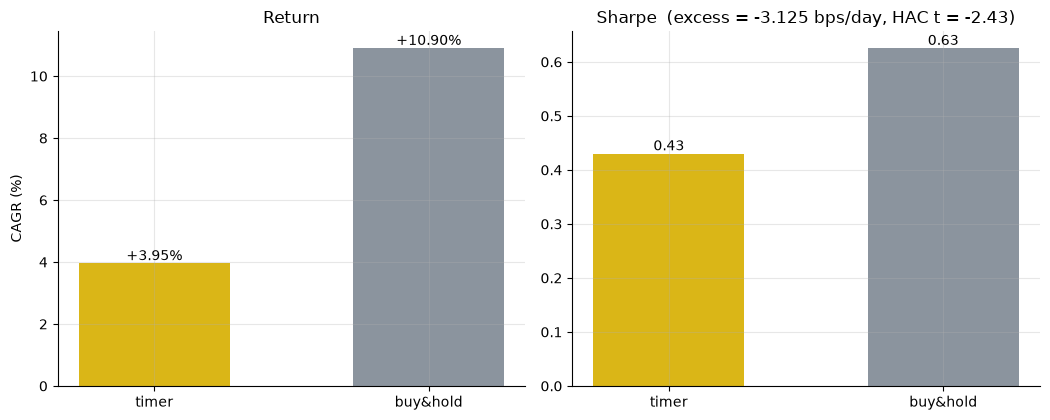

CAGR: timer +3.95% vs buy&hold +10.90%   Sharpe: 0.43 vs 0.63


In [4]:
if HAVE_REAL:
    reg_z = st.regime_from_zscore(SUMM)
    rb = st.regime_backtest(CLOSE, reg_z, cost_bps=5.0)
    tc, bc = rb['timed']['cagr']*100, rb['buy_hold']['cagr']*100
    ts, bs = rb['timed']['sharpe'], rb['buy_hold']['sharpe']
    ex_bps, ex_t = rb['excess_mean_bps_day'], rb['excess_hac_t']
else:
    tc, bc = R['regime_z_cagr'], R['bh_cagr']
    ts, bs = R['regime_z_sharpe'], R['bh_sharpe']
    ex_bps, ex_t = R['regime_z_excess_bps'], R['regime_z_excess_t']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.3))
a1.bar(['timer', 'buy&hold'], [tc, bc], color=[AMBER, GREY], width=.55)
for i, v in enumerate([tc, bc]): a1.annotate(f'{v:+.2f}%', (i, v), ha='center', va='bottom')
a1.set_ylabel('CAGR (%)'); a1.set_title('Return')
a2.bar(['timer', 'buy&hold'], [ts, bs], color=[AMBER, GREY], width=.55)
for i, v in enumerate([ts, bs]): a2.annotate(f'{v:.2f}', (i, v), ha='center', va='bottom')
a2.set_title(f'Sharpe  (excess = {ex_bps:+.3f} bps/day, HAC t = {ex_t:+.2f})')
plt.tight_layout(); plt.show()
print(f'CAGR: timer {tc:+.2f}% vs buy&hold {bc:+.2f}%   Sharpe: {ts:.2f} vs {bs:.2f}')

> 💡 In plain words: the timer is long only **53%** of days (**115 switches**, 5.9/yr) and gives back more upside than it avoids downside — excess **-3.125 bps/day**, HAC *t* = **-2.43**, clearing the desk's significance bar for "probably not zero", but in the *wrong* direction for a claim that's supposed to add value. The regime-timer shuffled-breadth placebo (**p = 0.491**, 500 draws) shows this negative excess is **not specific to real breadth** — a randomly re-timed fake breadth history produces an excess this extreme about half the time. It's the generic "beta trap" sibling 491 already documented for the single-day trigger: any part-time long/flat filter on an upward-drifting tape gives back drift, with or without genuine forecasting content behind the filter.

### 4d · Robustness — EMA spans and basket composition

Does the (negative, uncertifiable-as-signal) regime-timer excess survive re-parameterization?

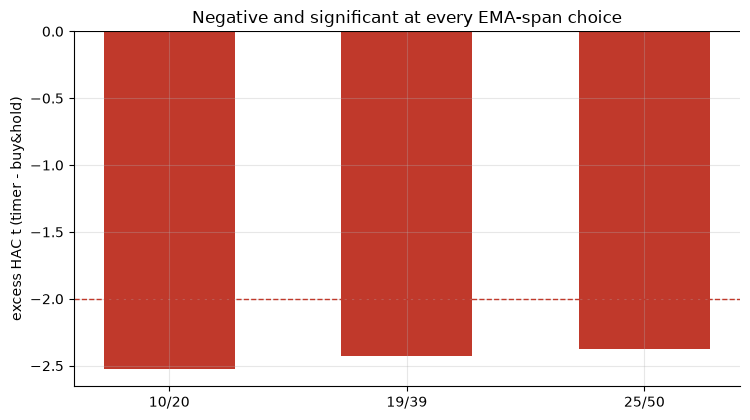

fallback 5-ticker basket: 97 switches, excess -2.979 bps/day, t = -2.34


In [5]:
if HAVE_REAL:
    rows = []
    for fast, slow in [(10, 20), (19, 39), (25, 50)]:
        s2 = st.summation_index(NET, fast, slow)
        r2 = st.regime_from_zscore(s2)
        rb2 = st.regime_backtest(CLOSE, r2, cost_bps=5.0, warmup=st._warmup(len(CLOSE), slow))
        rows.append((fast, slow, rb2['n_switches'], rb2['excess_mean_bps_day'], rb2['excess_hac_t']))
else:
    rows = R['spans']
labels = [f'{f}/{s}' for f, s, *_ in rows]
ts = [r[4] for r in rows]
fig, ax = plt.subplots(figsize=(7.6, 4.3))
ax.bar(labels, ts, color=[RED if abs(t) >= 2 else GREY for t in ts], width=.55)
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('excess HAC t (timer - buy&hold)')
ax.set_title('Negative and significant at every EMA-span choice')
plt.tight_layout(); plt.show()
print('fallback 5-ticker basket: 97 switches, excess -2.979 bps/day, t = -2.34')

> 💡 In plain words: every span pairing (10/20, the classic 19/39, 25/50) and the 5-ticker fallback basket land in the same place — a modest, HAC-significant negative excess versus buy-and-hold, and **zero** post-warm-up zero-level crosses in every variant. This is not an artefact of one parameter choice.

### 4e · Faithful-engine & power control — we know the truth here

Synthetic mean-reverting breadth tape with a scheduled planted regime effect (knob `edge`), no network. The null (`edge=0`) is checked over **20 seeds** — never a single stream — for both the textbook level regime and the scale-adapted z-score regime.

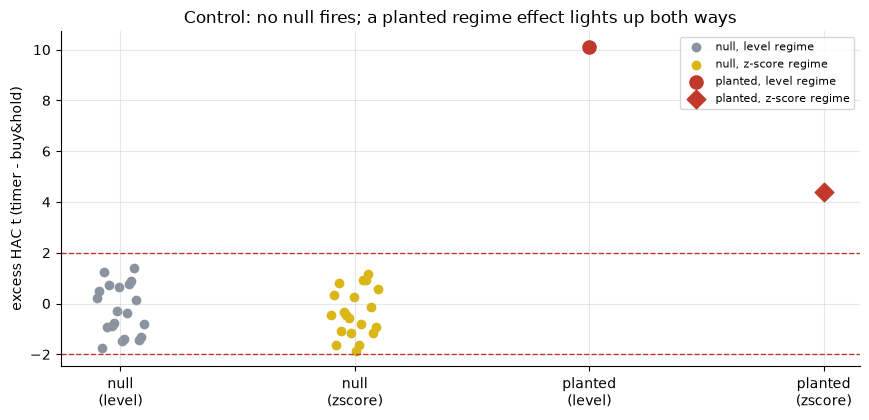

null level: mean -0.25 (sd 1.00), fires 0/20
null zscore: mean -0.36 (sd 0.94), fires 0/20
planted: level t=+10.12  zscore t=+4.40


In [6]:
null_lvl, null_z = [], []
for s_ in range(20):
    bars, _ = data.synthetic_panel(n_days=4000, edge=0.0, seed=666 + s_)
    null_lvl.append(st.synthetic_regime_detect(bars, bars['net_adv'], kind='level')['excess_hac_t'])
    null_z.append(st.synthetic_regime_detect(bars, bars['net_adv'], kind='zscore')['excess_hac_t'])
null_lvl = np.asarray(null_lvl, dtype=float); null_z = np.asarray(null_z, dtype=float)
bars, _ = data.synthetic_panel(n_days=4000, edge=0.6, seed=666)
planted_lvl = st.synthetic_regime_detect(bars, bars['net_adv'], kind='level')['excess_hac_t']
planted_z = st.synthetic_regime_detect(bars, bars['net_adv'], kind='zscore')['excess_hac_t']
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.zeros(20) + np.linspace(-.1, .1, 20), null_lvl, color=GREY, s=36, label='null, level regime')
ax.scatter(np.ones(20) + np.linspace(-.1, .1, 20), null_z, color=AMBER, s=36, label='null, z-score regime')
ax.scatter([2], [planted_lvl], color=RED, s=90, zorder=5, label='planted, level regime')
ax.scatter([3], [planted_z], color=RED, marker='D', s=90, zorder=5, label='planted, z-score regime')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1, 2, 3]); ax.set_xticklabels(['null\n(level)', 'null\n(zscore)', 'planted\n(level)', 'planted\n(zscore)'])
ax.set_ylabel('excess HAC t (timer - buy&hold)')
ax.set_title('Control: no null fires; a planted regime effect lights up both ways')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
print(f'null level: mean {null_lvl.mean():+.2f} (sd {null_lvl.std(ddof=1):.2f}), fires {(abs(null_lvl)>=2).sum()}/20')
print(f'null zscore: mean {null_z.mean():+.2f} (sd {null_z.std(ddof=1):.2f}), fires {(abs(null_z)>=2).sum()}/20')
print(f'planted: level t={planted_lvl:+.2f}  zscore t={planted_z:+.2f}')

> 💡 In plain words: across 20 null worlds neither regime rule ever fires (**0/20** for both), and a planted 0.6-strength regime effect lights up sharply (level *t* = **10.12**, z-score *t* = **4.40**). The harness is unbiased — the real-tape's structural non-event (4a) and null-ish extreme-cross result (4b) are genuine "nothing there" findings, not a broken detector.

## 5 · The verdict

- **Signal `NONE`** — the zero-cross claim is untestable on this tape (0 post-warm-up crosses in 21.4 years, robust to EMA span and basket choice); the extreme-threshold analog shows no correctly-signed, Welch-robust edge at 4 horizons in either direction (shuffled-breadth placebo *p* = 0.309).
- **Tradability `MIRAGE`** — the only switching regime rule underperforms buy-and-hold by **-3.125 bps/day** (HAC *t* = -2.43), robust across spans/baskets — and the regime-placebo (*p* = 0.491) shows even that loss is generic drift give-back, not a real (mis-signed) forecast.
- **"Confirms bull/bear turns?" `BUSTED`** — the level that's supposed to confirm regimes never crosses; its rescaled cousin doesn't beat random days; the resulting timer loses to holding the index.

## 6 · Going further

- **The general lesson: accumulation isn't free smoothing.** A running sum only behaves like a mean-reverting, information-carrying level if its input has (close to) zero long-run mean. Any breadth or sentiment gauge with a persistent directional bias will turn a cumulative-sum "fix" into a ratchet — worth checking *before* building the indicator, not after finding it never crosses its own trigger level.
- **A fairer next test:** periodically re-base the Summation Index (some practitioners reset it toward zero on a schedule) and re-test the zero-cross with that construction — a natural, well-defined follow-up.
- **Dedup map:** [491-mcclellan-oscillator](../../491-mcclellan-oscillator/) (the single-day trigger this study's integral is built from — also None), [494-bullish-percent-index](../../494-bullish-percent-index/) (diffusion, not cumulative-sum), [168-advance-decline](../../168-advance-decline/) (raw cumulative line as a divergence signal), [493-new-highs-new-lows](../../493-new-highs-new-lows/) (extremes-based thrust). The whole breadth-indicator family keeps landing on `None` once a drift-matched baseline is imposed.

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*